## HIPÓTESIS 2
## Paradigma del Punto Receptor con Integración Geoespacial

**Máster Big Data y Visual Analytics — UNIR**

---



---
## Importaciones y configuración global

In [5]:
import arcpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import time
import gc
import re
warnings.filterwarnings('ignore')

from scipy.interpolate  import NearestNDInterpolator
from sklearn.preprocessing  import StandardScaler, OneHotEncoder
from sklearn.compose        import ColumnTransformer
from sklearn.pipeline       import Pipeline
from sklearn.ensemble       import RandomForestRegressor
from sklearn.svm            import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection      import permutation_importance
from matplotlib.patches      import Patch

# ── Rutas del proyecto ────────────────────────────────────────────
GDB_PATH     = r'E:\MASTER_BIG_DATA\TFM_FINAL\PROCESOS\GDB_DATA.gdb'
RASTER_FUZZY = r'E:\MASTER_BIG_DATA\TFM_FINAL\PROCESOS\GDB_DATA.gdb\fuzzy_gama_07.tif'
FC_CATALOGO  = f'{GDB_PATH}\\Catalogo_Depurad_SpatialJoin'
FC_RESULTADO = f'{GDB_PATH}\\EXP4_DEFINITIVO'
CSV_SALIDA   = r'E:\MASTER_BIG_DATA\TFM_FINAL\PROCESOS\hip2_2500.csv'

# ── Parámetros globales ───────────────────────────────────────────
N_PUNTOS   = 2500       # puntos receptores
ALPHA      = 0.5        # amplificación fuzzy: factor ∈ [0.75, 1.25]
UMBRAL_KM  = 100        # umbral offshore para imputación
I_CLIP_MAX = 10         # máximo Mercalli Modificada para Ecuador
SEED       = 42
SR         = arcpy.SpatialReference(4326)

# Bounding box Ecuador continental
LAT_MIN, LAT_MAX = -5.5,  1.5
LON_MIN, LON_MAX = -81.5, -75.0

# Referencia H1 para contraste final
REF_H1_R2  = 0.544   # RF optimizado Experimento 1
REF_H1_MAE = 0.653

np.random.seed(SEED)
print('Librerías cargadas | Configuración global establecida')
print(f'  Puntos receptores : {N_PUNTOS:,}')
print(f'  Raster fuzzy      : {RASTER_FUZZY}')
print(f'  Catálogo FC       : {FC_CATALOGO}')
print(f'  Alpha fuzzy       : {ALPHA}  →  factor_sitio ∈ [{1-ALPHA*0.5:.2f}, {1+ALPHA*0.5:.2f}]')
print(f'  Umbral offshore   : {UMBRAL_KM} km')
print(f'  Clip intensidad   : [1, {I_CLIP_MAX}] escala Mercalli Modificada')

Librerías cargadas | Configuración global establecida
  Puntos receptores : 2,500
  Raster fuzzy      : E:\MASTER_BIG_DATA\TFM_FINAL\PROCESOS\GDB_DATA.gdb\fuzzy_gama_07.tif
  Catálogo FC       : E:\MASTER_BIG_DATA\TFM_FINAL\PROCESOS\GDB_DATA.gdb\Catalogo_Depurad_SpatialJoin
  Alpha fuzzy       : 0.5  →  factor_sitio ∈ [0.75, 1.25]
  Umbral offshore   : 100 km
  Clip intensidad   : [1, 10] escala Mercalli Modificada


---
## Sección 1 — Generación de 2.500 puntos receptores




In [6]:
# Muestreo aleatorio uniforme sobre Ecuador continental
np.random.seed(SEED)
df_puntos = pd.DataFrame({
    'punto_id': np.arange(N_PUNTOS),
    'lat'     : np.random.uniform(LAT_MIN, LAT_MAX, N_PUNTOS),
    'lon'     : np.random.uniform(LON_MIN, LON_MAX, N_PUNTOS),
})

# Crear Feature Class temporal en ArcGIS Pro para extracción geoespacial
FC_TEMP = f'{GDB_PATH}\\PUNTOS_RECEPTORES_TEMP'
if arcpy.Exists(FC_TEMP):
    arcpy.Delete_management(FC_TEMP)

arcpy.CreateFeatureclass_management(
    GDB_PATH, 'PUNTOS_RECEPTORES_TEMP', 'POINT', spatial_reference=SR)
arcpy.AddField_management(FC_TEMP, 'punto_id', 'LONG')

with arcpy.da.InsertCursor(FC_TEMP, ['SHAPE@XY', 'punto_id']) as cur:
    for _, row in df_puntos.iterrows():
        cur.insertRow([(float(row['lon']), float(row['lat'])),
                       int(row['punto_id'])])

print(f'Sección 1 completada:')
print(f'  Puntos generados : {len(df_puntos):,}')
print(f'  Latitud          : [{df_puntos["lat"].min():.3f}, {df_puntos["lat"].max():.3f}]')
print(f'  Longitud         : [{df_puntos["lon"].min():.3f}, {df_puntos["lon"].max():.3f}]')
print(f'  FC temporal      : {FC_TEMP}')
print(f'\nDistribución de puntos por región aproximada:')
costa   = df_puntos[df_puntos['lon'] < -78.5]
sierra  = df_puntos[(df_puntos['lon']>=-78.5) & (df_puntos['lon']<-77.0)]
amazonia= df_puntos[df_puntos['lon'] >= -77.0]
print(f'  Costa   (lon < -78.5°) : {len(costa):,} puntos ({len(costa)/N_PUNTOS*100:.1f}%)')
print(f'  Sierra  (-78.5 a -77°) : {len(sierra):,} puntos ({len(sierra)/N_PUNTOS*100:.1f}%)')
print(f'  Amazonía (lon > -77°)  : {len(amazonia):,} puntos ({len(amazonia)/N_PUNTOS*100:.1f}%)')

Sección 1 completada:
  Puntos generados : 2,500
  Latitud          : [-5.489, 1.498]
  Longitud         : [-81.500, -75.003]
  FC temporal      : E:\MASTER_BIG_DATA\TFM_FINAL\PROCESOS\GDB_DATA.gdb\PUNTOS_RECEPTORES_TEMP

Distribución de puntos por región aproximada:
  Costa   (lon < -78.5°) : 1,186 puntos (47.4%)
  Sierra  (-78.5 a -77°) : 563 puntos (22.5%)
  Amazonía (lon > -77°)  : 751 puntos (30.0%)


---
## Sección 2 — Extracción del valor fuzzy

Geoproceso `ExtractMultiValuesToPoints` sobre el raster de efectos de sitio (`fuzzy_gama_07.tif`, operador Gamma γ=0,7), con interpolación bilineal.  



In [8]:
# Extracción del valor fuzzy sobre los puntos receptores
# Interpolación BILINEAL para mayor precisión en el muestreo del raster
arcpy.sa.ExtractMultiValuesToPoints(
    FC_TEMP,
    [[RASTER_FUZZY, 'efecto_sitio_raw']],
    'BILINEAR'
)

# Leer valor extraído de vuelta al DataFrame
excluir   = {'OID','OBJECTID','Shape','Shape_Length','Shape_Area','punto_id'}
c_raster  = [f.name for f in arcpy.ListFields(FC_TEMP)
              if f.name not in excluir and not f.name.startswith('Shape')]

data_fz = arcpy.da.FeatureClassToNumPyArray(
    FC_TEMP, ['punto_id'] + c_raster,
    null_value={'Double': np.nan, 'Single': np.nan})
df_fz = pd.DataFrame(data_fz)

# Normalizar nombre de columna
if c_raster and c_raster[0] != 'efecto_sitio_raw':
    df_fz.rename(columns={c_raster[0]: 'efecto_sitio_raw'}, inplace=True)

df_puntos = df_puntos.merge(df_fz, on='punto_id', how='left')

n_ok   = df_puntos['efecto_sitio_raw'].notna().sum()
n_null = df_puntos['efecto_sitio_raw'].isna().sum()
print('Sección 2 completada — ExtractMultiValuesToPoints (bilineal):')
print(f'  Puntos con valor raster  : {n_ok:,} ({n_ok/N_PUNTOS*100:.1f}%)')
print(f'  Puntos sin valor (nulo)  : {n_null:,} ({n_null/N_PUNTOS*100:.1f}%) → Sección 3')
if n_ok > 0:
    s = df_puntos['efecto_sitio_raw'].dropna()
    print(f'  efecto_sitio_raw         : min={s.min():.3f} | max={s.max():.3f} | media={s.mean():.3f}')

Sección 2 completada — ExtractMultiValuesToPoints (bilineal):
  Puntos con valor raster  : 1,116 (44.6%)
  Puntos sin valor (nulo)  : 1,384 (55.4%) → Sección 3
  efecto_sitio_raw         : min=0.000 | max=0.887 | media=0.030


---
## Sección 3 — Imputación offshore

Los puntos sin cobertura del raster (offshore o zonas sin dato) reciben un valor imputado:  
- **≤ 100 km de la costa**: valor del punto terrestre más cercano (interpolación NearestND).  
- **> 100 km de la costa**: valor neutro 0,5 (factor_sitio = 1,0, sin corrección).


In [9]:
def haversine_km(la1, lo1, la2, lo2):
    """Distancia en km entre dos puntos geográficos (vectorizada)."""
    R = 6371.0
    p1, p2 = np.radians(la1), np.radians(la2)
    dp = np.radians(la2 - la1)
    dl = np.radians(lo2 - lo1)
    a  = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

# Distancia de cada punto a la costa (referencia: Manta, Ecuador)
df_puntos['dist_costa_km'] = haversine_km(
    df_puntos['lat'].values, df_puntos['lon'].values,
    -0.95, -80.72
)

mask_ok   = df_puntos['efecto_sitio_raw'].notna()
mask_null = ~mask_ok

if mask_null.sum() > 0:
    mask_near = mask_null & (df_puntos['dist_costa_km'] <= UMBRAL_KM)
    mask_far  = mask_null & (df_puntos['dist_costa_km'] >  UMBRAL_KM)

    # Imputación por vecino más cercano (≤ 100 km)
    if mask_near.sum() > 0:
        interp = NearestNDInterpolator(
            df_puntos.loc[mask_ok, ['lat','lon']].values,
            df_puntos.loc[mask_ok, 'efecto_sitio_raw'].values
        )
        df_puntos.loc[mask_near, 'efecto_sitio_raw'] = interp(
            df_puntos.loc[mask_near, ['lat','lon']].values
        )

    # Valor neutro para puntos muy offshore (> 100 km)
    df_puntos.loc[mask_far, 'efecto_sitio_raw'] = 0.5

# Clip al rango [0, 1]
df_puntos['efecto_sitio_raw'] = df_puntos['efecto_sitio_raw'].clip(0, 1)

print('Sección 3 completada — Imputación offshore:')
if mask_null.sum() > 0:
    print(f'  Imputados por vecino   : {mask_near.sum():,} puntos (≤ {UMBRAL_KM} km costa)')
    print(f'  Valor neutro (0.5)     : {mask_far.sum():,} puntos (> {UMBRAL_KM} km costa)')
else:
    print('  No hubo puntos sin cobertura')
print(f'  efecto_sitio_raw final : min={df_puntos["efecto_sitio_raw"].min():.3f}'
      f' | max={df_puntos["efecto_sitio_raw"].max():.3f}')

# Calcular factor_sitio: corrección multiplicativa centrada en 1.0
# factor_sitio = 1 + α*(efecto_sitio_raw - 0.5)  →  rango [0.75, 1.25] con α=0.5
df_puntos['factor_sitio'] = (1 + ALPHA * (df_puntos['efecto_sitio_raw'] - 0.5)).clip(0.75, 1.25)
print(f'  factor_sitio           : min={df_puntos["factor_sitio"].min():.3f}'
      f' | max={df_puntos["factor_sitio"].max():.3f} | neutro=1.000')

# Eliminar FC temporal
arcpy.Delete_management(FC_TEMP)

Sección 3 completada — Imputación offshore:
  Imputados por vecino   : 68 puntos (≤ 100 km costa)
  Valor neutro (0.5)     : 1,316 puntos (> 100 km costa)
  efecto_sitio_raw final : min=0.000 | max=0.887
  factor_sitio           : min=0.750 | max=1.193 | neutro=1.000


<Result 'true'>

---
## Sección 4 — Cálculo vectorizado de intensidad

Aplicación de las **leyes de atenuación de Aguiar (2014)** sobre los 11.600.000 pares punto-receptor × sismo del catálogo, mediante operaciones NumPy en bloques.  

| Tipo de fuente | Ley de atenuación |
|---|---|
| Crustal | I = 3,756 + 1,586·Mw − 1,861·ln(D+10) |
| Subducción (interface / in-slab) | I = −1,484 + 1,402·Mw − 0,545·ln(D+10) |

Donde D = √(R² + h²) es la distancia hipocentral en km, R la distancia epicentral (fórmula de Haversine) y h la profundidad focal.  
La intensidad resultante se recorta al rango [1, 10] de la escala de Mercalli Modificada.


In [10]:
# Carga del catálogo sísmico depurado desde la GDB
FIELDS_CAT = ['SHAPE@X','SHAPE@Y','mag','depth','Tipo',
               'MMax','Strike','Rake','Dip','b_num','es_mainshock','Depth_rang']
campos_fc  = {f.name for f in arcpy.ListFields(FC_CATALOGO)}
fields_ok  = [f for f in FIELDS_CAT
               if f in campos_fc or f.startswith('SHAPE')]

data_cat = arcpy.da.FeatureClassToNumPyArray(
    FC_CATALOGO, fields_ok,
    null_value={'Double':np.nan,'Single':np.nan,
                'Integer':-9999,'SmallInteger':-9999})
df_cat = pd.DataFrame(data_cat)
df_cat.rename(columns={'SHAPE@X':'lon_s','SHAPE@Y':'lat_s'}, inplace=True)
df_cat.replace(-9999, np.nan, inplace=True)
df_cat.dropna(subset=['mag','depth','lat_s','lon_s'], inplace=True)
df_cat['depth'] = df_cat['depth'].clip(lower=0.1)
df_cat['Tipo']  = df_cat['Tipo'].astype(str).str.strip().str.lower()
df_cat.reset_index(drop=True, inplace=True)
N_SISMOS = len(df_cat)

# Arrays NumPy para cálculo vectorizado
lat_s_r  = np.radians(df_cat['lat_s'].values)
lon_s_r  = np.radians(df_cat['lon_s'].values)
Mw_arr   = df_cat['mag'].values
h_arr    = df_cat['depth'].values
es_c_arr = (df_cat['Tipo'] == 'crustal sources').values

lat_p_all = np.radians(df_puntos['lat'].values)
lon_p_all = np.radians(df_puntos['lon'].values)

R_TIERRA = 6371.0
BLOQUE   = 500
n_bloq   = int(np.ceil(N_PUNTOS / BLOQUE))

# Arrays de salida
I_mat_max  = np.zeros(N_PUNTOS)       # I_max por punto
idx_s_max  = np.zeros(N_PUNTOS, dtype=int)  # índice del sismo causante
I_mat_p90  = np.zeros(N_PUNTOS)       # percentil 90 de I
n_gt4_arr  = np.zeros(N_PUNTOS, dtype=int)  # eventos con I≥4
n_gt6_arr  = np.zeros(N_PUNTOS, dtype=int)  # eventos con I≥6

t0 = time.time()
print(f'Catálogo: {N_SISMOS:,} sismos depurados')
print(f'Pares a calcular: {N_PUNTOS:,} × {N_SISMOS:,} = {N_PUNTOS*N_SISMOS:,}')
print(f'Procesando en {n_bloq} bloques de {BLOQUE} puntos...\n')

for b in range(n_bloq):
    ini = b * BLOQUE
    fin = min(ini + BLOQUE, N_PUNTOS)
    lat_p = lat_p_all[ini:fin, None]   # (fin-ini, 1)
    lon_p = lon_p_all[ini:fin, None]

    # Distancia epicentral Haversine (km)
    dphi = lat_s_r[None, :] - lat_p
    dlam = lon_s_r[None, :] - lon_p
    a    = (np.sin(dphi/2)**2 +
            np.cos(lat_p) * np.cos(lat_s_r[None, :]) * np.sin(dlam/2)**2)
    R_km = 2 * R_TIERRA * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

    # Distancia hipocentral
    D = np.sqrt(R_km**2 + h_arr[None, :]**2)

    # Leyes de atenuación Aguiar (2014)
    I_c = 3.756  + 1.586 * Mw_arr[None, :] - 1.861 * np.log(D + 10)  # crustal
    I_s = -1.484 + 1.402 * Mw_arr[None, :] - 0.545 * np.log(D + 10)  # subducción
    I   = np.clip(np.where(es_c_arr[None, :], I_c, I_s), 1, I_CLIP_MAX)

    I_mat_max[ini:fin]  = I.max(axis=1)
    idx_s_max[ini:fin]  = I.argmax(axis=1)
    I_mat_p90[ini:fin]  = np.percentile(I, 90, axis=1)
    n_gt4_arr[ini:fin]  = (I >= 4).sum(axis=1)
    n_gt6_arr[ini:fin]  = (I >= 6).sum(axis=1)

    del R_km, D, I_c, I_s, I, a, dphi, dlam
    gc.collect()

    if (b+1) % 2 == 0 or b == n_bloq-1:
        print(f'  Bloque {b+1:>2}/{n_bloq} '
              f'({(b+1)/n_bloq*100:.0f}%) — {time.time()-t0:.0f}s')

df_puntos['I_max']          = I_mat_max
df_puntos['I_p90']          = I_mat_p90
df_puntos['n_sismos_I_gt4'] = n_gt4_arr
df_puntos['n_sismos_I_gt6'] = n_gt6_arr
df_puntos['idx_sismo_max']  = idx_s_max

print(f'\nSección 4 completada en {time.time()-t0:.1f}s')
print(f'  I_max por punto : min={I_mat_max.min():.2f} | max={I_mat_max.max():.2f}'
      f' | media={I_mat_max.mean():.2f}')

Catálogo: 4,640 sismos depurados
Pares a calcular: 2,500 × 4,640 = 11,600,000
Procesando en 5 bloques de 500 puntos...

  Bloque  2/5 (40%) — 1s
  Bloque  4/5 (80%) — 1s
  Bloque  5/5 (100%) — 2s

Sección 4 completada en 1.7s
  I_max por punto : min=7.17 | max=10.00 | media=7.67


---
## Sección 5 — Cálculo de I_max_corr

Extracción de la intensidad máxima histórica por punto receptor y corrección multiplicativa por el factor de sitio derivado del modelo fuzzy:  

```
I_max_corr = clip( I_max × factor_sitio, 1, 10 )
```

Esta variable constituye el **target del modelo de Machine Learning**.


Sección 5 completada — Cálculo de I_max_corr:
  Formula: I_max_corr = clip(I_max × factor_sitio, 1, 10)

  Variable              Min    Max   Media     Std
  ----------------------------------------------
  I_max               7.171 10.000   7.667   0.406
  I_max_corr          5.482 10.000   6.813   0.907
  I_p90               1.943  2.908   2.376   0.196
  I_p90_corr          1.521  3.084   2.107   0.279
  factor_sitio        0.750  1.193   0.891   0.124


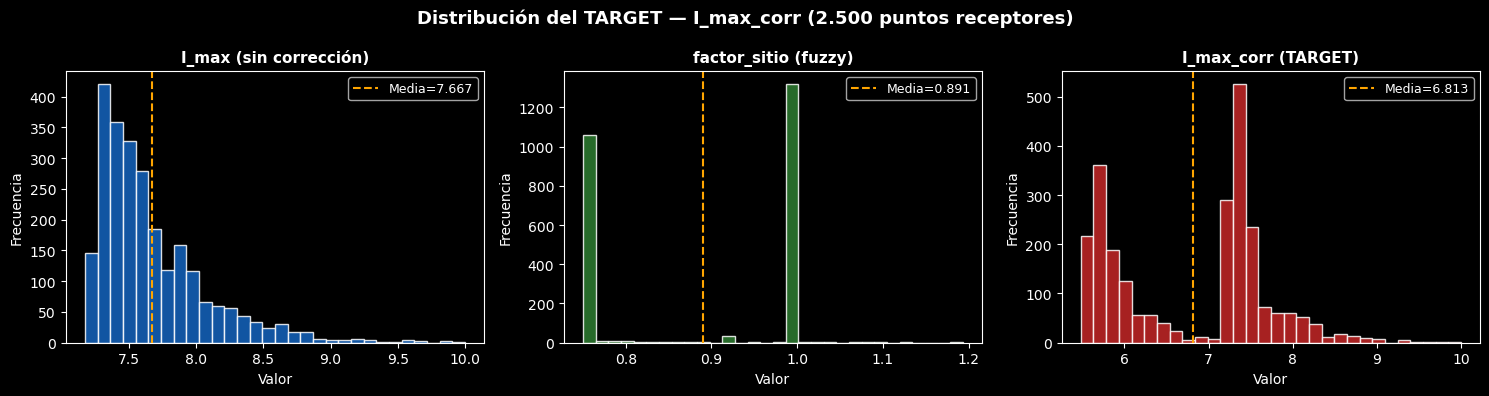

In [11]:
# Corrección multiplicativa por factor de sitio geoespacial
# I_max_corr es el TARGET del modelo ML (Hipótesis 2)
df_puntos['I_max_corr'] = np.clip(
    df_puntos['I_max'] * df_puntos['factor_sitio'],
    1, I_CLIP_MAX
).round(4)

df_puntos['I_p90_corr'] = np.clip(
    df_puntos['I_p90'] * df_puntos['factor_sitio'],
    1, I_CLIP_MAX
).round(4)

print('Sección 5 completada — Cálculo de I_max_corr:')
print(f'  Formula: I_max_corr = clip(I_max × factor_sitio, 1, {I_CLIP_MAX})')
print(f'\n  {"Variable":<18} {"Min":>6} {"Max":>6} {"Media":>7} {"Std":>7}')
print(f'  {"-"*46}')
for col in ['I_max','I_max_corr','I_p90','I_p90_corr','factor_sitio']:
    d = df_puntos[col]
    print(f'  {col:<18} {d.min():>6.3f} {d.max():>6.3f} '
          f'{d.mean():>7.3f} {d.std():>7.3f}')

# Visualización distribución TARGET
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color, titulo in [
    (axes[0], 'I_max',      '#1565C0', 'I_max (sin corrección)'),
    (axes[1], 'factor_sitio','#2E7D32','factor_sitio (fuzzy)'),
    (axes[2], 'I_max_corr', '#C62828', 'I_max_corr (TARGET)'),
]:
    ax.hist(df_puntos[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.axvline(df_puntos[col].mean(), color='orange', linestyle='--',
               label=f'Media={df_puntos[col].mean():.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribución del TARGET — I_max_corr (2.500 puntos receptores)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sección 6 — Dataset de modelado

Construcción del dataset final de 2.500 filas combinando:  
- **Variables del punto receptor**: lat, lon, efecto_sitio_raw, factor_sitio  
- **Variables del sismo causante**: características del evento sísmico que generó I_max en cada punto  

> **Nota metodológica**: se excluyen `fecha` y `n_replicas` por constituir variables con leakage temporal — solo están disponibles después de la ocurrencia del evento.


In [12]:
# Ingeniería de características del catálogo sísmico
df_cat['depth_log']        = np.log1p(df_cat['depth'].clip(lower=0))
df_cat['es_mainshock_bin'] = df_cat.get('es_mainshock', pd.Series(1, index=df_cat.index)).apply(
    lambda x: 1 if str(x).strip().lower() in ['true','1','yes','si','mainshock'] else 0
)
def mapear_depth_rang(val):
    if pd.isna(val): return np.nan
    nums = re.findall(r'\d+', str(val))
    if not nums: return np.nan
    n = int(nums[0])
    return 0 if n<35 else 1 if n<70 else 2 if n<150 else 3

if 'Depth_rang' in df_cat.columns:
    df_cat['depth_rang_ord'] = df_cat['Depth_rang'].apply(mapear_depth_rang)

for col in ['MMax','Strike','Rake','Dip','b_num','depth_rang_ord','es_mainshock_bin']:
    if col in df_cat.columns:
        df_cat[col].fillna(df_cat[col].median(), inplace=True)

# Variables a extraer del sismo causante
VARS_SISMO_NUM = [v for v in ['mag','depth_log','MMax','Strike','Rake',
                               'Dip','b_num','es_mainshock_bin','depth_rang_ord']
                   if v in df_cat.columns]
VARS_SISMO_CAT = ['Tipo'] if 'Tipo' in df_cat.columns else []

# Extraer características del sismo causante (el que generó I_max en cada punto)
idx_causante = df_puntos['idx_sismo_max'].values
df_causante  = df_cat.iloc[idx_causante][VARS_SISMO_NUM + VARS_SISMO_CAT].reset_index(drop=True)
df_causante.columns = ['sismo_' + c for c in df_causante.columns]

# Dataset final
COLS_PUNTO = ['punto_id','lat','lon','efecto_sitio_raw','factor_sitio',
              'I_max','I_max_corr','I_p90','I_p90_corr',
              'n_sismos_I_gt4','n_sismos_I_gt6']
df_model = pd.concat([
    df_puntos[COLS_PUNTO].reset_index(drop=True),
    df_causante.reset_index(drop=True)
], axis=1)

print('Sección 6 completada — Dataset de modelado:')
print(f'  Filas    : {df_model.shape[0]:,} (una por punto receptor)')
print(f'  Columnas : {df_model.shape[1]}')
print(f'\n  {"Columna":<28} {"Tipo":<15} {"Grupo"}')
print(f'  {"-"*58}')
for col in df_model.columns:
    if col in ['punto_id','lat','lon','efecto_sitio_raw','factor_sitio']:
        grupo = 'Punto receptor'
    elif 'I_max' in col or 'I_p90' in col:
        grupo = 'TARGET / auxiliar'
    elif col.startswith('sismo_'):
        grupo = 'Sismo causante'
    else:
        grupo = 'Auxiliar'
    print(f'  {col:<28} {str(df_model[col].dtype):<15} {grupo}')

# Exportar CSV del dataset completo
df_model.round(4).to_csv(CSV_SALIDA, index=False)
print(f'\nDataset exportado: {CSV_SALIDA}')

Sección 6 completada — Dataset de modelado:
  Filas    : 2,500 (una por punto receptor)
  Columnas : 21

  Columna                      Tipo            Grupo
  ----------------------------------------------------------
  punto_id                     int64           Punto receptor
  lat                          float64         Punto receptor
  lon                          float64         Punto receptor
  efecto_sitio_raw             float32         Punto receptor
  factor_sitio                 float32         Punto receptor
  I_max                        float64         TARGET / auxiliar
  I_max_corr                   float64         TARGET / auxiliar
  I_p90                        float64         TARGET / auxiliar
  I_p90_corr                   float64         TARGET / auxiliar
  n_sismos_I_gt4               int64           Auxiliar
  n_sismos_I_gt6               int64           Auxiliar
  sismo_mag                    float64         Sismo causante
  sismo_depth_log              float6

---
## Sección 7 — Entrenamiento y validación espacial

Pipeline de RF, SVR y MLP con división **80/20 por punto receptor**.  
500 puntos geográficamente distintos a los del entrenamiento forman el conjunto de prueba, controlando la autocorrelación espacial propia de los fenómenos sísmicos.


In [13]:
# ── Definición de features y target ─────────────────────────────
FEATS_PUNTO_NUM = ['lat','lon','efecto_sitio_raw','factor_sitio']
FEATS_SISMO_NUM = ['sismo_mag','sismo_depth_log','sismo_MMax',
                   'sismo_Strike','sismo_Rake','sismo_Dip',
                   'sismo_b_num','sismo_es_mainshock_bin']
FEATS_SISMO_CAT = ['sismo_Tipo']
if 'sismo_depth_rang_ord' in df_model.columns:
    FEATS_SISMO_NUM.append('sismo_depth_rang_ord')

NUM_FEATURES = [f for f in FEATS_PUNTO_NUM + FEATS_SISMO_NUM if f in df_model.columns]
CAT_FEATURES = [f for f in FEATS_SISMO_CAT if f in df_model.columns]
TARGET       = 'I_max_corr'

# Preparar X e y
df_ml = df_model[NUM_FEATURES + CAT_FEATURES + [TARGET]].copy()
for col in NUM_FEATURES:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')
    df_ml[col].fillna(df_ml[col].median(), inplace=True)
if CAT_FEATURES:
    df_ml[CAT_FEATURES[0]] = df_ml[CAT_FEATURES[0]].astype(str).str.strip().str.lower()
df_ml.dropna(subset=[TARGET], inplace=True)

print(f'Features numéricas  : {NUM_FEATURES}')
print(f'Features categóricas: {CAT_FEATURES}')
print(f'Target              : {TARGET}')

# ── Split 80/20 POR PUNTO RECEPTOR ───────────────────────────────
# Garantiza que el modelo se evalúa sobre ubicaciones geográficas
# nunca vistas durante el entrenamiento (validación espacial)
puntos_ids = df_model['punto_id'].values.copy()
np.random.seed(SEED)
np.random.shuffle(puntos_ids)
n_test    = int(len(puntos_ids) * 0.20)  # 500 puntos nuevos
pts_test  = set(puntos_ids[:n_test])
pts_train = set(puntos_ids[n_test:])

mask_train = df_model['punto_id'].isin(pts_train)
mask_test  = df_model['punto_id'].isin(pts_test)
X_train = df_ml.loc[mask_train, NUM_FEATURES + CAT_FEATURES]
y_train = df_ml.loc[mask_train, TARGET]
X_test  = df_ml.loc[mask_test,  NUM_FEATURES + CAT_FEATURES]
y_test  = df_ml.loc[mask_test,  TARGET]

print(f'\nSplit espacial por punto receptor:')
print(f'  Train: {len(pts_train):,} puntos ({len(pts_train)/N_PUNTOS*100:.0f}%)')
print(f'  Test : {len(pts_test):,} puntos ({len(pts_test)/N_PUNTOS*100:.0f}%) — nunca vistos en entrenamiento')

Features numéricas  : ['lat', 'lon', 'efecto_sitio_raw', 'factor_sitio', 'sismo_mag', 'sismo_depth_log', 'sismo_MMax', 'sismo_Strike', 'sismo_Rake', 'sismo_Dip', 'sismo_b_num', 'sismo_es_mainshock_bin', 'sismo_depth_rang_ord']
Features categóricas: ['sismo_Tipo']
Target              : I_max_corr

Split espacial por punto receptor:
  Train: 2,000 puntos (80%)
  Test : 500 puntos (20%) — nunca vistos en entrenamiento


In [14]:
# ── Preprocesador y modelos ───────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
]) if CAT_FEATURES else ColumnTransformer([('num', StandardScaler(), NUM_FEATURES)])

# n_jobs=1 obligatorio: ArcGIS Pro no soporta paralelización en Notebook
models = {
    'Random Forest': Pipeline([('pre', preprocessor),
        ('reg', RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=1))]),
    'SVR': Pipeline([('pre', preprocessor),
        ('reg', SVR(kernel='rbf', C=10, gamma=0.1))]),
    'MLP': Pipeline([('pre', preprocessor),
        ('reg', MLPRegressor(hidden_layer_sizes=(128,64,32), activation='tanh',
                             alpha=0.01, max_iter=1000, random_state=SEED,
                             early_stopping=True))]),
}

results = {}
predictions = {}
COLORS_MOD = {'Random Forest':'#2196F3','SVR':'#F44336','MLP':'#4CAF50'}

print(f'{"Modelo":<18} {"MAE":>8} {"RMSE":>8} {"R²":>8}  {"CV R² (5-fold)":>18}  {"ΔR² vs H1":>10}')
print('-'*78)

for name, pipeline in models.items():
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[name] = (y_pred, y_test.values)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2', n_jobs=1)
    dr2  = r2 - REF_H1_R2

    results[name] = {'MAE':mae,'RMSE':rmse,'R2':r2,
                     'CV_mean':cv.mean(),'CV_std':cv.std(),'DR2':dr2}

    print(f'{name:<18} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}  '
          f'{cv.mean():>6.3f} ± {cv.std():.3f}      '
          f'{"+" if dr2>=0 else ""}{dr2:+.3f}  ({time.time()-t0:.0f}s)')

print(f'\nReferencia Hipótesis 1 (RF optimizado): R²={REF_H1_R2} | MAE={REF_H1_MAE}')

Modelo                  MAE     RMSE       R²      CV R² (5-fold)   ΔR² vs H1
------------------------------------------------------------------------------
Random Forest        0.0315   0.0970   0.9890   0.987 ± 0.005      ++0.445  (5s)
SVR                  0.0793   0.1597   0.9701   0.971 ± 0.007      ++0.426  (0s)
MLP                  0.0603   0.1558   0.9715   0.974 ± 0.006      ++0.428  (12s)

Referencia Hipótesis 1 (RF optimizado): R²=0.544 | MAE=0.653


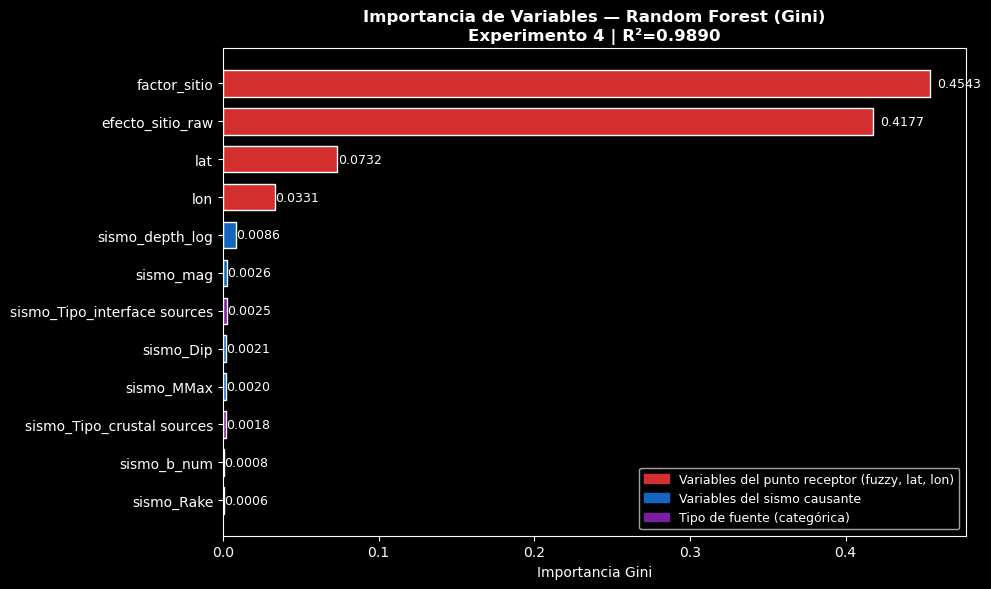


Contribución del índice fuzzy (factor_sitio):
  Posición en ranking : 1 de 15
  Importancia Gini    : 0.4543 (45.4%)
  Vars punto receptor : 0.9784 (97.8%)
  Vars sismo causante : 0.0216 (2.2%)


In [15]:
# ── Importancia de variables (RF: Gini | SVR, MLP: Permutation) ──
rf_pipe   = models['Random Forest']
rf_model  = rf_pipe.named_steps['reg']
pre_fit   = rf_pipe.named_steps['pre']
try:
    ohe_cats  = pre_fit.named_transformers_['cat'].get_feature_names_out(CAT_FEATURES)
    feat_names = NUM_FEATURES + list(ohe_cats)
except:
    feat_names = NUM_FEATURES

imp_rf = pd.Series(rf_model.feature_importances_,
                    index=feat_names).sort_values(ascending=False)

# Gráfico de importancia RF (top 12)
fig, ax = plt.subplots(figsize=(10, 6))
top12   = imp_rf.head(12).sort_values(ascending=True)
colors_bar = [
    '#D32F2F' if f in FEATS_PUNTO_NUM   # rojo: variables del punto receptor
    else '#7B1FA2' if 'sismo_Tipo' in f  # morado: tipo de fuente
    else '#1565C0'                       # azul: sismo causante
    for f in top12.index
]
bars = ax.barh(range(len(top12)), top12.values,
               color=colors_bar, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top12)))
ax.set_yticklabels(top12.index, fontsize=10)
for bar, val in zip(bars, top12.values):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
leyenda = [
    Patch(color='#D32F2F', label='Variables del punto receptor (fuzzy, lat, lon)'),
    Patch(color='#1565C0', label='Variables del sismo causante'),
    Patch(color='#7B1FA2', label='Tipo de fuente (categórica)'),
]
ax.legend(handles=leyenda, fontsize=9, loc='lower right')
ax.set_title('Importancia de Variables — Random Forest (Gini)\n'
             f'Experimento 4 | R²={results["Random Forest"]["R2"]:.4f}',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importancia Gini', fontsize=10)
plt.tight_layout()
plt.show()

# Resumen contribución factor_sitio
fs_imp  = imp_rf.get('factor_sitio', 0)
fs_rank = list(imp_rf.index).index('factor_sitio') + 1 if 'factor_sitio' in imp_rf.index else 'N/A'
imp_pto = imp_rf[imp_rf.index.isin(FEATS_PUNTO_NUM)].sum()
imp_sis = imp_rf[~imp_rf.index.isin(FEATS_PUNTO_NUM)].sum()
print(f'\nContribución del índice fuzzy (factor_sitio):')
print(f'  Posición en ranking : {fs_rank} de {len(imp_rf)}')
print(f'  Importancia Gini    : {fs_imp:.4f} ({fs_imp*100:.1f}%)')
print(f'  Vars punto receptor : {imp_pto:.4f} ({imp_pto*100:.1f}%)')
print(f'  Vars sismo causante : {imp_sis:.4f} ({imp_sis*100:.1f}%)')

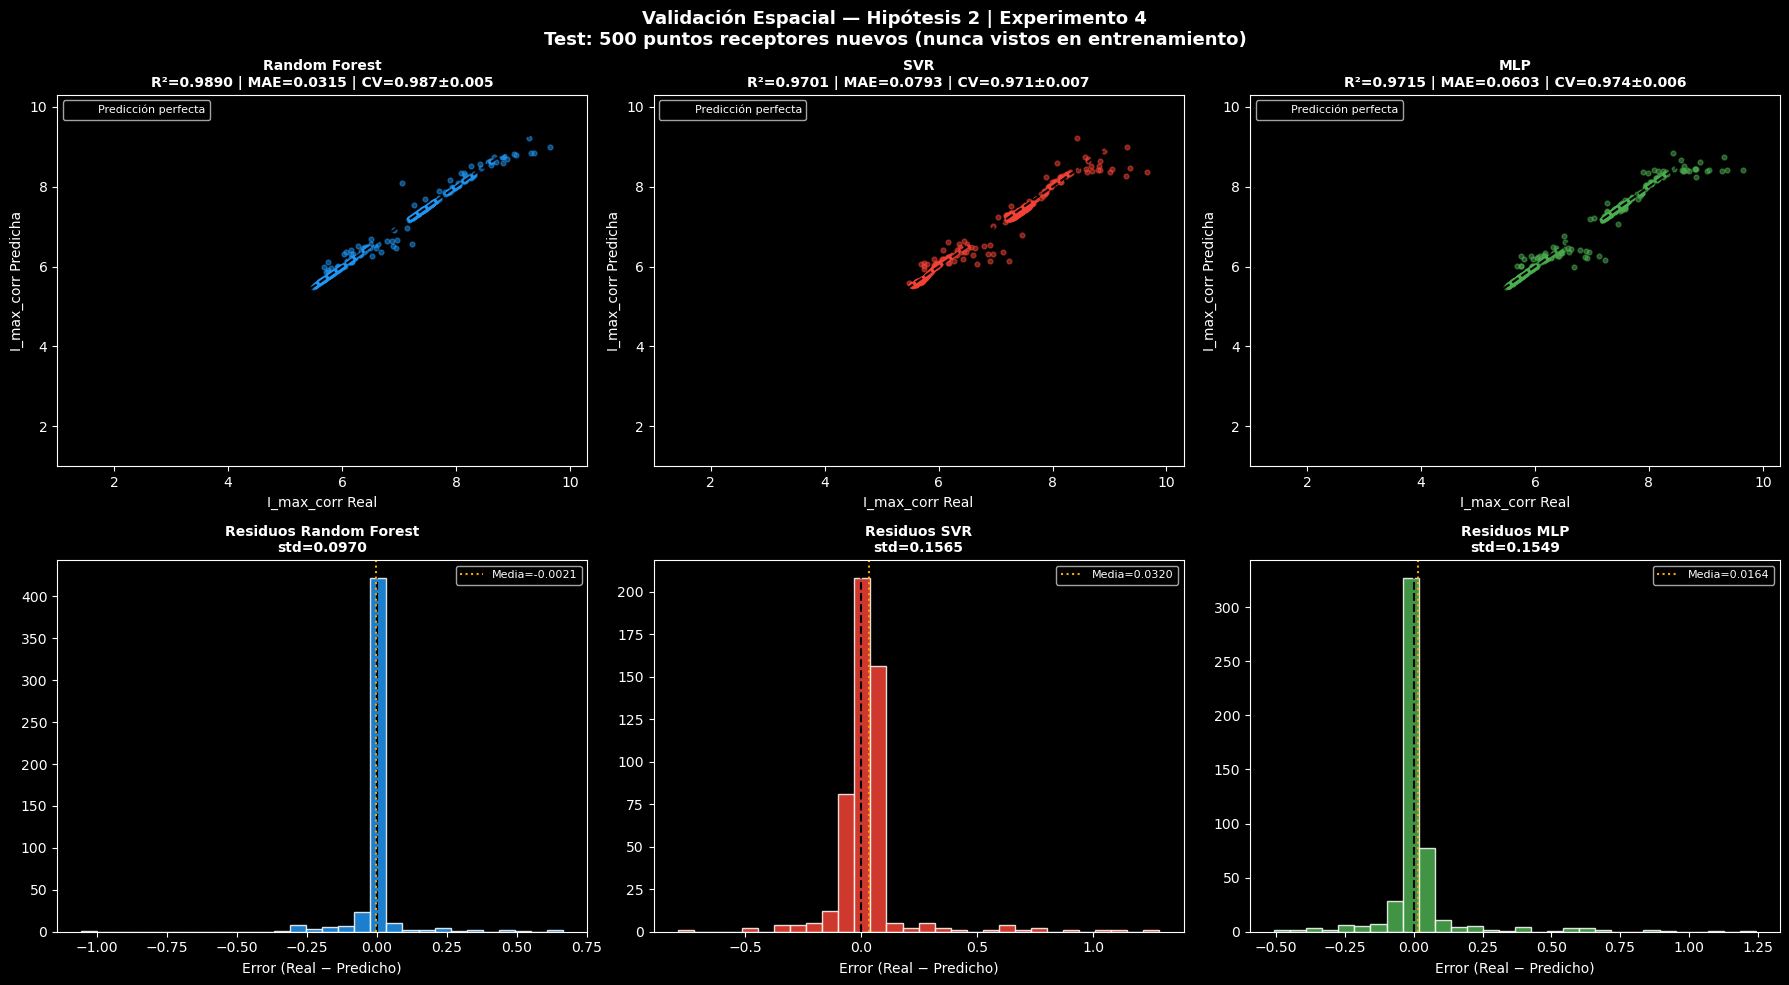

<class 'arcgisscripting.ExecuteError'>: Failed to execute. Parameters are not valid.
ERROR 000732: Input Table: Dataset E:\MASTER_BIG_DATA\TFM_FINAL\PROCESOS\GDB_DATA.gdb\HIPO_2 does not exist or is not supported
Failed to execute (AddField).


In [16]:
# ── Gráficos Reales vs Predichos y Residuos (3 modelos) ──────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (name, (y_pred, y_real)) in enumerate(predictions.items()):
    m   = results[name]
    res = y_real - y_pred

    # Reales vs predichos
    axes[0,col].scatter(y_real, y_pred, alpha=0.5, s=12, color=COLORS_MOD[name])
    axes[0,col].plot([1, I_CLIP_MAX], [1, I_CLIP_MAX], 'k--', linewidth=1.5,
                     label='Predicción perfecta')
    axes[0,col].set_xlim([1, I_CLIP_MAX+0.3]); axes[0,col].set_ylim([1, I_CLIP_MAX+0.3])
    axes[0,col].set_xlabel('I_max_corr Real', fontsize=10)
    axes[0,col].set_ylabel('I_max_corr Predicha', fontsize=10)
    axes[0,col].set_title(f'{name}\nR²={m["R2"]:.4f} | MAE={m["MAE"]:.4f} | CV={m["CV_mean"]:.3f}±{m["CV_std"]:.3f}',
                           fontweight='bold', fontsize=10)
    axes[0,col].legend(fontsize=8)

    # Distribución de residuos
    axes[1,col].hist(res, bins=30, color=COLORS_MOD[name], edgecolor='white', alpha=0.85)
    axes[1,col].axvline(0, color='black', linestyle='--', linewidth=1.5)
    axes[1,col].axvline(res.mean(), color='orange', linestyle=':',
                        label=f'Media={res.mean():.4f}')
    axes[1,col].set_title(f'Residuos {name}\nstd={res.std():.4f}',
                           fontweight='bold', fontsize=10)
    axes[1,col].set_xlabel('Error (Real − Predicho)', fontsize=10)
    axes[1,col].legend(fontsize=8)

plt.suptitle(
    'Validación Espacial — Hipótesis 2 | Experimento 4\n'
    f'Test: {len(pts_test):,} puntos receptores nuevos (nunca vistos en entrenamiento)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Exportar FC resultado a ArcGIS Pro ────────────────────────────
rf_pred_all = models['Random Forest'].predict(df_ml[NUM_FEATURES + CAT_FEATURES])
df_model['I_pred_RF'] = rf_pred_all

if arcpy.Exists(FC_RESULTADO): arcpy.Delete_management(FC_RESULTADO)
arcpy.CreateFeatureclass_management(GDB_PATH, 'EXP4_DEFINITIVO', 'POINT', spatial_reference=SR)
for nombre, tipo in [
    ('punto_id','LONG'),('efecto_sitio_raw','DOUBLE'),('factor_sitio','DOUBLE'),
    ('I_max','DOUBLE'),('I_max_corr','DOUBLE'),('I_pred_RF','DOUBLE'),
    ('n_I_gt4','LONG'),('n_I_gt6','LONG'),
]:
    arcpy.AddField_management(FC_RESULTADO, nombre, tipo)

with arcpy.da.InsertCursor(FC_RESULTADO,
    ['SHAPE@XY','punto_id','efecto_sitio_raw','factor_sitio',
     'I_max','I_max_corr','I_pred_RF','n_I_gt4','n_I_gt6']) as cur:
    for _, row in df_model.iterrows():
        cur.insertRow([
            (float(row['lon']), float(row['lat'])),
            int(row['punto_id']),
            float(row['efecto_sitio_raw']),
            float(row['factor_sitio']),
            float(row['I_max']),
            float(row['I_max_corr']),
            float(row['I_pred_RF']),
            int(row['n_sismos_I_gt4']),
            int(row['n_sismos_I_gt6']),
        ])

n_fc = int(arcpy.GetCount_management(FC_RESULTADO)[0])
print(f'\nSección 7 completada:')
print(f'  FC resultado : EXP4_DEFINITIVO ({n_fc:,} puntos)')
print(f'  Próximos pasos: IDW/Kriging → raster amenaza 80m en ArcGIS Pro')
print(f'\n{"="*60}')
print('RESULTADOS FINALES — HIPÓTESIS 2 vs HIPÓTESIS 1')
print(f'{"="*60}')
print(f'{"Modelo":<18} {"R²":>8} {"MAE":>8} {"RMSE":>8}  {"CV R²":>16}  {"ΔR² vs H1":>10}')
print('-'*75)
for name, m in results.items():
    print(f'{name:<18} {m["R2"]:>8.4f} {m["MAE"]:>8.4f} '
          f'{m["RMSE"]:>8.4f}  {m["CV_mean"]:>6.3f}±{m["CV_std"]:.3f}  '
          f'{"+" if m["DR2"]>=0 else ""}{m["DR2"]:+.3f}')
print(f'\nReferencia H1: R²={REF_H1_R2} | MAE={REF_H1_MAE}')
print(f'factor_sitio : posición {fs_rank} de {len(imp_rf)} | Gini={fs_imp:.4f}')